In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, cohen_kappa_score, roc_auc_score, average_precision_score, PrecisionRecallDisplay, precision_recall_curve, recall_score
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.naive_bayes import GaussianNB,  CategoricalNB
from sklearn.base import BaseEstimator, ClassifierMixin


## Load data

In [2]:
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-1.085628,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0
1,3,0.420314,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0


In [3]:
# Define columns
continuous_features = ['child_weight']
categorical_features = [
    'child_age', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area',
    'child_sex', 'mother_education', 'health_insurance', 'wealth_index'
]
one_hot_provinces = [
    'province_1.0', 'province_2.0', 'province_3.0', 'province_4.0',
    'province_5.0', 'province_6.0', 'province_7.0'
]
target = 'malnurished'

# Separate datasets
X_cont = df[continuous_features]
X_cat = df[categorical_features + one_hot_provinces]
y = df[target]

### Train test split

In [4]:
# Train/test split
X_cont_train, X_cont_test, X_cat_train, X_cat_test, y_train, y_test = train_test_split(
    X_cont, X_cat, y, test_size=0.2, random_state=42
)

X_train_combined = pd.concat([X_cont_train.reset_index(drop=True), X_cat_train.reset_index(drop=True)], axis=1)

In [5]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_combined, y_train)

X_cont_train_sm = X_train_sm[continuous_features]
X_cat_train_sm = X_train_sm.drop(columns=continuous_features)

In [6]:
print('Before SMOTE: ', Counter(y_train))
print('After SMOTE: ', Counter(y_train_sm))

Before SMOTE:  Counter({0: 2828, 1: 2316})
After SMOTE:  Counter({1: 2828, 0: 2828})


# Naive Bayes

### Base model

In [7]:
# Train models
gnb = GaussianNB()
cnb = CategoricalNB()

gnb.fit(X_cont_train_sm, y_train_sm)
cnb.fit(X_cat_train_sm, y_train_sm)

CategoricalNB()

In [8]:
# Predict
log_prob_cont = gnb.predict_log_proba(X_cont_test)
log_prob_cat = cnb.predict_log_proba(X_cat_test)

log_prob_combined = log_prob_cont + log_prob_cat

In [9]:
y_pred = np.argmax(log_prob_combined, axis=1)
print("Classification Report:\n", classification_report(y_test, y_pred, digits=3))

Classification Report:
               precision    recall  f1-score   support

           0      0.692     0.610     0.648       707
           1      0.584     0.668     0.623       579

    accuracy                          0.636      1286
   macro avg      0.638     0.639     0.636      1286
weighted avg      0.643     0.636     0.637      1286



In [10]:
prob_combined = np.exp(log_prob_combined) # convert log probs to probabilities
y_probas = prob_combined[:, 1] 

# Compute Average Precision Score
average_precision_score(y_test, y_probas)

0.6163719474228703

## Hyperparameter Tuning

In [11]:
class HybridNB(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha=1.0, fit_prior=True, var_smoothing=1e-9,
                 cont_features=None, cat_features=None):
        self.alpha = alpha
        self.fit_prior = fit_prior
        self.var_smoothing = var_smoothing
        self.cont_features = cont_features
        self.cat_features = cat_features

    def fit(self, X, y):
        self.gnb = GaussianNB(var_smoothing=self.var_smoothing)
        self.cnb = CategoricalNB(alpha=self.alpha, fit_prior=self.fit_prior)

        X_cont = X[self.cont_features]
        X_cat = X[self.cat_features]

        self.gnb.fit(X_cont, y)
        self.cnb.fit(X_cat, y)

        self.classes_ = self.gnb.classes_
        return self

    def predict(self, X):
        log_prob_combined = self._get_combined_log_probs(X)
        return self.classes_[np.argmax(log_prob_combined, axis=1)]

    def predict_proba(self, X):
        log_prob_combined = self._get_combined_log_probs(X)
        return np.exp(log_prob_combined)

    def _get_combined_log_probs(self, X):
        X_cont = X[self.cont_features]
        X_cat = X[self.cat_features]

        log_prob_cont = self.gnb.predict_log_proba(X_cont)
        log_prob_cat = self.cnb.predict_log_proba(X_cat)

        # Ensure class order matches
        assert np.array_equal(self.gnb.classes_, self.cnb.classes_)
        return log_prob_cont + log_prob_cat


In [12]:
X_train_combined = pd.concat([
    X_cont_train_sm.reset_index(drop=True),
    X_cat_train_sm.reset_index(drop=True)
], axis=1)

# Combine test set the same way
X_test_combined = pd.concat([
    X_cont_test.reset_index(drop=True),
    X_cat_test.reset_index(drop=True)
], axis=1)


In [13]:
# Scorer for positive class (malnourished = 1)
recall_scorer = make_scorer(recall_score, pos_label=1)

# Parameter grid
param_grid = {
    'alpha': [0.1, 0.45, 0.5, 0.6, 1.0],
    'fit_prior': [True, False],
    'var_smoothing': [1e-10, 1e-9, 1e-8]
}

# Instantiate model
hybrid_model = HybridNB(
    cont_features=continuous_features,
    cat_features=X_cat_train_sm.columns.tolist()
)

# Grid search
grid_search = GridSearchCV(
    estimator=hybrid_model,
    param_grid=param_grid,
    scoring=recall_scorer,
    cv=10,
    verbose=1,
    n_jobs=-1
)

# Fit
grid_search.fit(X_train_combined, y_train_sm)


Fitting 10 folds for each of 30 candidates, totalling 300 fits


GridSearchCV(cv=10,
             estimator=HybridNB(cat_features=['child_age',
                                              'diarrhoea_last_2_weeks',
                                              'fever_last_2_weeks', 'area',
                                              'child_sex', 'mother_education',
                                              'health_insurance',
                                              'wealth_index', 'province_1.0',
                                              'province_2.0', 'province_3.0',
                                              'province_4.0', 'province_5.0',
                                              'province_6.0', 'province_7.0'],
                                cont_features=['child_weight']),
             n_jobs=-1,
             param_grid={'alpha': [0.1, 0.45, 0.5, 0.6, 1.0],
                         'fit_prior': [True, False],
                         'var_smoothing': [1e-10, 1e-09, 1e-08]},
             scoring=make_scorer(recall_score, pos_label=1), verbose=1)

In [14]:
print("Best Parameters:", grid_search.best_params_)
print(f"Best cross-validation recall score: {grid_search.best_score_:.3f}")

Best Parameters: {'alpha': 0.5, 'fit_prior': True, 'var_smoothing': 1e-10}
Best cross-validation recall score: 0.654


In [15]:
nb_tune = grid_search.best_estimator_

# Predict on test
y_pred_tune = nb_tune.predict(X_test_combined)
print("Classification Report:\n", classification_report(y_test, y_pred_tune, digits=3))


Classification Report:
               precision    recall  f1-score   support

           0      0.692     0.610     0.648       707
           1      0.584     0.668     0.623       579

    accuracy                          0.636      1286
   macro avg      0.638     0.639     0.636      1286
weighted avg      0.643     0.636     0.637      1286



### Average Precision Score

In [16]:
y_probas_tune = nb_tune.predict_proba(X_test_combined)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas_tune)}')

Average Precision: 0.616353392015474


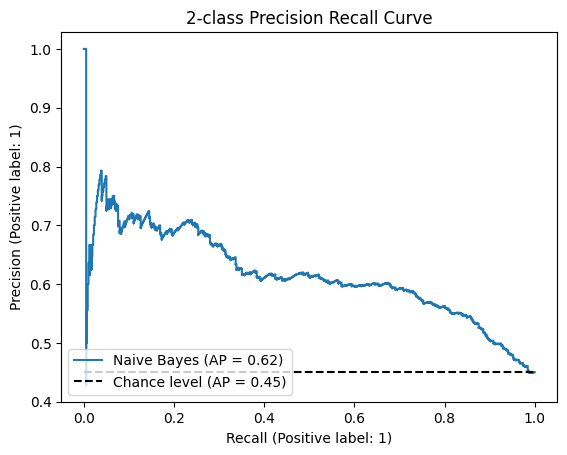

In [17]:
display = PrecisionRecallDisplay.from_predictions(
    y_test,
    prob_combined[:, 1],        # Probability for class 1 (malnourished)
    name="Naive Bayes",
    plot_chance_level=True
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()


### Recall score on train set

In [18]:
# Recall on base model
log_prob_cont_train = gnb.predict_log_proba(X_cont_train_sm)
log_prob_cat_train = cnb.predict_log_proba(X_cat_train_sm)
log_prob_combined_train = log_prob_cont_train + log_prob_cat_train
y_train_pred = np.argmax(log_prob_combined_train, axis=1)
train_recall = recall_score(y_train_sm, y_train_pred)
print(f"Recall on Training set (Base Model): {train_recall:.3f}")

# Recall on tune tune model
y_train_pred = nb_tune.predict(X_train_sm)
train_recall = recall_score(y_train_sm, y_train_pred)
print(f"Recall on Training set (Tune Model): {train_recall:.3f}")

Recall on Training set (Base Model): 0.654
Recall on Training set (Tune Model): 0.654


### AUC score

In [19]:
auc = roc_auc_score(y_test, y_probas)
print(f"AUC: {auc:.3f}")

auc_tune = roc_auc_score(y_test, y_probas_tune)
print(f"AUC: {auc_tune:.3f}")

AUC: 0.688
AUC: 0.688


In [20]:
kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa: {kappa:.3f}")

kappa_tune = cohen_kappa_score(y_test, y_pred_tune)
print(f"Cohen's Kappa: {kappa_tune:.3f}")

Cohen's Kappa: 0.274
Cohen's Kappa: 0.274


### Confusion matrix

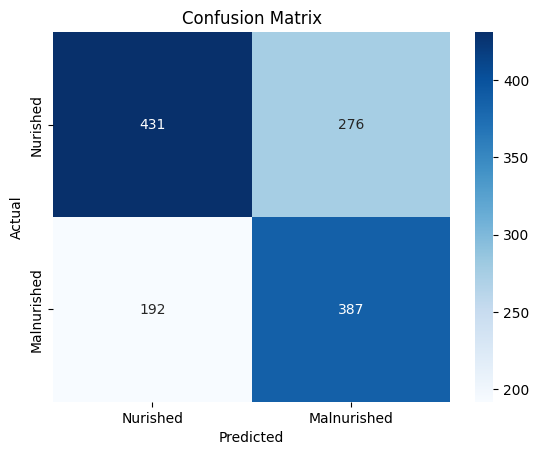

In [21]:
cm = confusion_matrix(y_test, y_pred_tune)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Additional

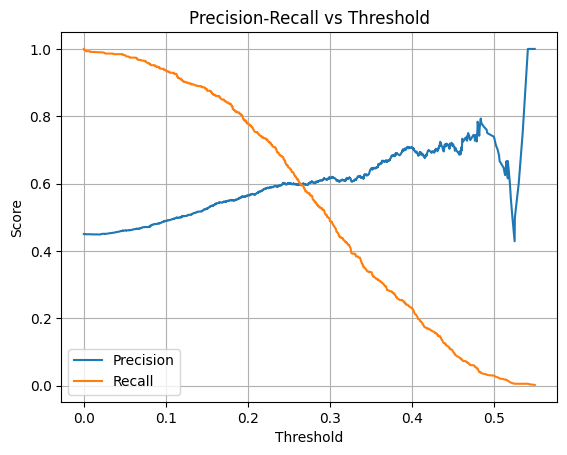

In [22]:
precision, recall, thresholds = precision_recall_curve(y_test, y_probas_tune)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [23]:
# Apply custom threshold
y_probas_custom = (y_probas_tune >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.59      0.92      0.72       707
           1       0.71      0.23      0.35       579

    accuracy                           0.61      1286
   macro avg       0.65      0.58      0.53      1286
weighted avg       0.64      0.61      0.55      1286


